# 03 — H3 security / material audit (human review)

Functional classification: emotional security vs material/economic security vs status
display. Classify interaction **function**, not the object mentioned (a gown can be
status display, gift-as-care, or neither).

Saved Pass A/B/C + evidence packets only; rating cells stay blinded.
Special focus: leaf `1.6` (appearance) — Stage 10 found it on-label but the H3 question
is whether appearance content is doing *security* work.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
root = cwd
for _ in range(6):
    if (root / "configs").is_dir() and (root / "src").is_dir():
        break
    root = root.parent
sys.path.insert(0, str(root))

from src.stage11_refined_construct_analysis.analysis import notebook_helpers as nh
from src.stage11_refined_construct_analysis.analysis import review_display as rd
from src.stage11_refined_construct_analysis.analysis.constructs import normalize_code

ctx = nh.setup("03_h3_security_material_audit")
cfg = ctx.cfg
HYP = "H3"
CODE_COL = "security_code"

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage11/refined_constructs.yaml
Run          : v4_l12_granular_final_call49
Outputs      : results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit


## 1. Overview — every H3 topic with labels

In [2]:
master = nh.load_master(cfg)
h3 = master[master[CODE_COL].notna()].copy()
h3["code_norm"] = h3[CODE_COL].map(normalize_code)
print(f"H3-coded topics: {len(h3)}")

overview = rd.annotation_overview(h3, CODE_COL, extra_cols=["secondary_id"])
display(overview[["topic", "taxonomy", "code", "code_norm", "mixed", "agree"]].head(60))
ctx.save_table(overview, "h3_topic_overview_labeled")
display(h3[CODE_COL].value_counts().head(20).to_frame("n"))
display(h3["code_norm"].value_counts(dropna=False).to_frame("n_norm"))

H3-coded topics: 90


,topic,taxonomy,code,code_norm,mixed,agree
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S0,S0,False,H3
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,S2,S2,False,H3
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,S0,S0,False,H3
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,S0,S0,False,
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,S0,S0,False,
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,S13,S13,False,H3


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_topic_overview_labeled.csv  (90 rows)


,n
security_code,
S0,65
S13,6
S1,4
S4,3
S5,3
S7,2
S2,2
S6,1
S11,1


,n_norm
code_norm,
S0,65
S13,6
S1,4
S4,3
S5,3
S7,2
S2,2
S6,1
S11,1


## 2. Lexical vs contextual agreement

In [3]:
lex = nh.load_audit_jsonl(cfg, HYP, "A")
ctxu = nh.load_audit_jsonl(cfg, HYP, "B")
adj = nh.load_audit_jsonl(cfg, HYP, "C")
lex_idx = rd.audit_index(lex)
ctx_idx = rd.audit_index(ctxu)
adj_idx = rd.audit_index(adj)

agree = rd.agreement_table(h3, lex_idx, ctx_idx, adj_idx, hyp=HYP)
if not agree.empty:
    print(
        f"Lexical–contextual agreement: {agree['agree'].mean():.1%} "
        f"({int(agree['agree'].sum())}/{len(agree)})"
    )
    ctx.save_table(agree, "h3_lexical_contextual_agreement")
    disagree = agree[~agree["agree"]]
    print(f"Disagreements: {len(disagree)}")
    display(
        disagree[
            ["topic", "taxonomy", "code_a", "code_b", "code_c", "rationale_a", "rationale_b"]
        ].head(30)
    )

Lexical–contextual agreement: 53.3% (48/90)
  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_lexical_contextual_agreement.csv  (90 rows)
Disagreements: 42


,topic,taxonomy,code_a,code_b,code_c,rationale_a,rationale_b
5,27 — Racing The Approaching Storm,"7.3 — Risk, Danger & External Crises",S7,S0,S7,"Keywords like 'rain', 'snow', 'storm', 'dark',...",Most sentences describe weather conditions or ...
13,52 — Talking About Dogs and Animals,4.2 — Ongoing Courtship & Everyday Relational ...,S6,S0,S0,"Main keywords (dog, pet, puppy, bear, lion) ar...",The overwhelming majority of sentences in this...
16,59 — Mother's Disapproval Looms,"5.1 — Family, Kinship & Parenthood",S1,S0,S0,The keyword cluster centres on mother-child re...,The overwhelming majority of sentences in this...
17,61 — Planning to Exchange Rings,8.3a — Commitment Symbols & Love Tokens,S14,MIXED,S4,"All four keyword lists centre on rings, neckla...",Topic 61 centres on jewellery and body adornme...
19,65 — Declaring A True Partnership,"4.5 — Reconciliation, Commitments & HEA",S4,S2,S4,"Main keywords (date, dating, together, dated, ...",The topic centers on romantic pairing and shar...
21,75 — Talking About Being A Father,"5.1 — Family, Kinship & Parenthood",S1,S0,S0,All four keyword lists converge on father-chil...,All sentences in this topic reference father/d...
23,81 — Mentioning A Brother,"5.1 — Family, Kinship & Parenthood",S2,S0,S0,"Main keywords (brother, brothers, siblings, si...",The overwhelming majority of sentences in this...
24,83 — Reassured About Eating Regularly,"4.6 — Emotional Safety, Reassurance & Caretaking",S5,S0,S5,"All four keyword lists centre on eating, hunge...",The overwhelming majority of sentences are sim...
25,86 — First Name Used at Last,4.2 — Ongoing Courtship & Everyday Relational ...,S1,S0,S0,"Main keywords (name, nickname, real, knew) poi...",The overwhelming majority of sentences are sim...
27,93 — Meal Plans Casually Arranged,4.2 — Ongoing Courtship & Everyday Relational ...,S5,S2,S2,All four keyword lists converge on shared meal...,The topic centres on shared meals — invitation...


## 3. Appearance leaf (`1.6`) functional decomposition

What to check in the cards: is the prose describing bodies/clothes as craft ornament,
as wealth/status signalling, or as care/security? The object in the sentence is not the
construct.

In [4]:
app = h3[h3["current_taxonomy_id"] == "1.6"].copy()
print(f"Appearance topics in H3 audit: {len(app)}")
app_overview = rd.annotation_overview(app, CODE_COL, extra_cols=["secondary_id"])
display(app_overview[["topic", "taxonomy", "code", "code_norm", "mixed", "secondary_id"]])
ctx.save_table(app_overview, "h3_appearance_decomposition")

cross = (
    h3.assign(
        taxonomy=h3.apply(
            lambda r: rd.fmt_leaf(r["current_taxonomy_id"], r["current_taxonomy_name"]),
            axis=1,
        )
    )
    .groupby(["taxonomy", "current_taxonomy_id", "code_norm"], dropna=False)
    .size()
    .rename("n")
    .reset_index()
    .sort_values("n", ascending=False)
)
display(cross.head(40))
ctx.save_table(cross, "h3_taxonomy_vs_code")

Appearance topics in H3 audit: 15


,topic,taxonomy,code,code_norm,mixed,secondary_id
0,18 — Ordering A Gown For Her,1.6 — Character Appearance & Self-Presentation,S13,S13,False,6.6
1,77 — Haircut and Grooming Offered,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None
2,127 — Photographer Reviewing Pictures,1.6 — Character Appearance & Self-Presentation,S0,S0,False,None
3,170 — Staying Close Despite Long Separation,1.6 — Character Appearance & Self-Presentation,S2,S2,False,4.2
4,171 — Staring at Her Own Reflection,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None
5,192 — Peeking Through The Window,1.6 — Character Appearance & Self-Presentation,S0,S0,False,8.2
6,209 — Flowers Held With Guilty Glance,1.6 — Character Appearance & Self-Presentation,S0,S0,False,4.2
7,218 — Resenting Someone More Attractive,1.6 — Character Appearance & Self-Presentation,S13,S13,False,3.2
8,241 — Calling Someone A Stubborn Idiot,1.6 — Character Appearance & Self-Presentation,S0,S0,False,3.2
9,253 — Hair Pinned Up in Style,1.6 — Character Appearance & Self-Presentation,S13,S13,False,None


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_appearance_decomposition.csv  (15 rows)


,taxonomy,current_taxonomy_id,code_norm,n
10,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S0,22
3,4.2 — Ongoing Courtship & Everyday Relational ...,4.2,S0,13
0,1.6 — Character Appearance & Self-Presentation,1.6,S0,8
1,1.6 — Character Appearance & Self-Presentation,1.6,S13,6
29,"8.2 — Public, Travel & Leisure Spaces",8.2,S0,4
18,"5.1 — Family, Kinship & Parenthood",5.1,S0,4
6,"4.5 — Reconciliation, Commitments & HEA",4.5,S0,4
14,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S5,2
17,4.7 — Jealousy & Possessive Romance Conflict,4.7,S0,2
11,"4.6 — Emotional Safety, Reassurance & Caretaking",4.6,S1,2


  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/h3_taxonomy_vs_code.csv  (31 rows)


## 4. Close reading

Priority: appearance topics, disagreements, mixed, then stratified sample by code.

Close-reading 71 of 90 topics (disagreements / mixed / manual / stratified sample).

  TOPIC 18 — Ordering A Gown For Her
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : S13  (norm: S13)
  Stage08 snippets:
      · he’ll make sure you have a dress worthy of you.”
      · i’ll order a gown for you and have it sent to the house.” “
      · we’ll have to borrow their clothes.” “
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=middle, p=0.63]
        I did not mean to hurt your feelings about your attention to the womanly details of
        dress and appearance and wished to compensate you for the loss of the gown you’ve
        been wearing to work with Wilfrid.”
    · [BOOK_001, CELL_D, tertile=end, p=0.60]
        Mayhap if you were clothed when you attempted it, Edmee might have accepted it?” “’
    · [BOOK_001, CELL_D, tertile=middle, p=0.57]
        Her gown should be clean and her hair always groomed and under a veil. “
    · [BOOK_002, CELL_C, tertile=m

  TOPIC 170 — Staying Close Despite Long Separation
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : S2  (norm: S2)
  Stage08 snippets:
      · despite going months without talking to each other—their daily lives hectic enough
      · that even living in the same city had never ensured regular visits—they were close.
      · my guess is they’ve been seeing each other the whole time.
      · they might've solved his problems together.
  Novel sentences:
    · [BOOK_002, CELL_B, tertile=end, p=0.67]
        It was strange how they’d met, almost as if it was fated to happen sooner or later.
        “
  Pass A/B/C:
    A lexical: S2
        Main keywords (together, relationship, couple, between, both, them) and
        KeyBERT/MMR cues (closely, separated, shared, spending, separated) all point to
        the security function of belonging — the togetherness or separateness of a pair
        and their relational bond. POS keywords (separate, session, visits, scenari

  TOPIC 218 — Resenting Someone More Attractive
  Taxonomy : 1.6 — Character Appearance & Self-Presentation
  Code     : S13  (norm: S13)
  Stage08 snippets:
      · the human in charge of maintaining his harem was moderately dishevelled from the
      · panic, but he was, as always, poised and visually attractive.
      · i think he’s still trying to prove that he is mister attractive and can make anyone
      · fall in love with him.’ ‘
      · how could i even begin to like someone who was:  a) gorgeous, thereby making me,
      · someone who until now was considered pretty decent looking, seem, at best, perfectly
  Novel sentences:
    · [BOOK_002, CELL_C, tertile=middle, p=0.69]
        He was so handsome, so kind, so sweet and funny with his little boy.
    · [BOOK_002, CELL_C, tertile=end, p=0.69]
        He was, in her opinion, too handsome for his own good, too smooth for anyone else’s.
    · [BOOK_002, CELL_C, tertile=middle, p=0.69]
        And looked gorgeous doing it, he 

  TOPIC 27 — Racing The Approaching Storm
  Taxonomy : 7.3 — Risk, Danger & External Crises
  Code     : S7  (norm: S7)
  Stage08 snippets:
      · it’ll be dark before we know it.’’
      · i don’t know if i’ll be able to get back here before the storm hits.
      · it’s going to rain and we’ll be caught out in the storm.
  Novel sentences:
    · [BOOK_001, CELL_D, tertile=end, p=0.52]
        Their lips met, and an explosion of passion took them along on a tide, the darkness
        that surrounded them like a blanket against the rest of the world.
    · [BOOK_001, CELL_D, tertile=begin, p=0.46]
        Just as they reached the spot a man strode angrily out of a neighbouring field, and
        even in the poor light his expression could be seen as thunderous.
    · [BOOK_001, CELL_D, tertile=begin, p=0.44]
        They were still driving, the high hedges making it impossible for them to see
        anything but the road in front of them.
  Pass A/B/C:
    A lexical: S7
        Keywor

  TOPIC 351 — Warm Greeting Upon Return
  Taxonomy : 4.2 — Ongoing Courtship & Everyday Relational Bonding
  Code     : S0  (norm: S0)
  Stage08 snippets:
      · thank god you’ve come back—and will you look at me, just in time.”
      · it is a pleasure to see you again—so soon, madam. ”
      · so i’ll see you there,” he said, feeling upbeat for the first time in a long time. “
  Novel sentences:
    · [BOOK_002, CELL_D, tertile=begin, p=0.52]
        I’ll see you as often as I can,” he said, only making matters worse by reminding the
        children he wouldn’t be seeing them on a normal basis. “
    · [BOOK_002, CELL_D, tertile=middle, p=0.37]
        Amber had seen it as a splendid way to say goodbye to the hoards of tourists who
        crowded Harmony during that season.
  Pass A/B/C:
    A lexical: S1
        All four keyword sets converge on the lexical field of warm social
        acknowledgment: Main keywords (glad, happy, pleasure, nice, great) signal
        positive affe

  TOPIC 174 — Ranch Life and Falling in Love
  Taxonomy : 4.2 — Ongoing Courtship & Everyday Relational Bonding
  Code     : S0  (norm: S0)
  Stage08 snippets:
      · i’ve seen your willy on numerous occasions on the ranch.
      · the ranch is doing good, and i’ve fallen in love.
      · i’d take you there, but i imagine you’ve already seen enough cattle to last you a
      · lifetime.”
  Novel sentences:
    · [BOOK_002, CELL_B, tertile=end, p=0.54]
        I’ll fetch some water, and then could you sit with him while I fetch the farmer’s
        wife?” “
    · [BOOK_002, CELL_B, tertile=end, p=0.52]
        That’s as much as I can do—we’re busy at the farm, and the lad isn’t in danger.”
    · [BOOK_002, CELL_B, tertile=middle, p=0.51]
        They got milk, cheese, eggs and other produce from the farm, and they would soon be
        easily able to grow enough herbs and vegetables for their own use.
    · [BOOK_002, CELL_B, tertile=middle, p=0.47]
        When the resident died, the 

  TOPIC 260 — Crowd Goes Wild For Him
  Taxonomy : 8.2 — Public, Travel & Leisure Spaces
  Code     : S0  (norm: S0)
  Stage08 snippets:
      · he played crazier than i’ve ever seen him, and from the way the crowd was going
      · insane with cheering around me, cam played even crazier than anyone had ever seen
      · but it's a madness i've had all my life.
      · you see, i’ve gone and done something a little crazy.
  Novel sentences:
    · [BOOK_002, CELL_B, tertile=end, p=0.53]
        He was going to drive himself insane if he didn't get out of the apartment.
    · [BOOK_003, CELL_D, tertile=middle, p=0.52]
        Terri swallowed thickly wondering if she really was as crazy as Joel accused her of
        being.
    · [BOOK_004, CELL_C, tertile=middle, p=0.40]
        He has just enough training to make him totally freak out every single day.” “
  Pass A/B/C:
    A lexical: S0
        Main keywords (crazy, insane, madness, craziness, going, think) describe
        mental/emoti

  saved table: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/tables/security_topic_annotations.csv  (90 rows)


  saved figure: results/stage11_refined_construct_analysis/v4_l12_granular_final_call49/notebook_analysis/03_h3_security_material_audit/figures/h3_code_distribution.png


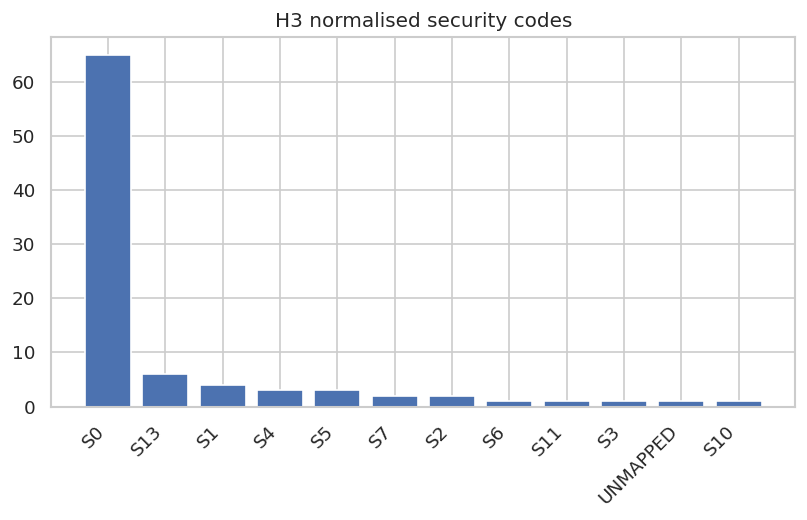

H3 audit review complete.


In [5]:
review_ids = rd.select_review_topics(
    h3,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    force_ids=app["topic_id"].tolist(),
    per_code=3,
    seed=42,
)
packs = rd.show_review_set(
    cfg,
    h3,
    review_ids,
    hyp=HYP,
    lex_idx=lex_idx,
    ctx_idx=ctx_idx,
    adj_idx=adj_idx,
    code_col=CODE_COL,
)
ctx.save_markdown(
    rd.render_review_markdown(packs, title="H3 security / material — close-reading pack"),
    "close_reading_pack",
)
ctx.save_table(
    h3[
        [
            "topic_id",
            "current_topic_label",
            "current_taxonomy_id",
            "current_taxonomy_name",
            "security_code",
            "code_norm",
            "mixed_topic",
        ]
    ],
    "security_topic_annotations",
)

fig, ax = plt.subplots(figsize=(8, 4))
vc = h3["code_norm"].fillna("UNMAPPED").value_counts()
ax.bar(vc.index.astype(str), vc.values)
ax.set_title("H3 normalised security codes")
plt.xticks(rotation=45, ha="right")
ctx.save_figure(fig, "h3_code_distribution")
plt.show()

print("H3 audit review complete.")